# Decision Tree Regressor
Predicting Total Cost (USD)

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')

## Load & Prepare Data

In [2]:
df = pd.read_csv('../data/final_data.csv')
print('Shape:', df.shape)
print('\n--- Cleaning summary ---')
print('total_cost_usd NaN:', df['total_cost_usd'].isna().sum())

# Feature engineering
df['ship_date'] = pd.to_datetime(df['ship_date'], errors='coerce')
df['delivery_date'] = pd.to_datetime(df['delivery_date'], errors='coerce')

df['delivery_days'] = (df['delivery_date'] - df['ship_date']).dt.days
df['cost_per_kg'] = df['total_cost_usd'] / df['weight_kg'].replace(0, np.nan)
df['volume_per_kg'] = df['volume_m3'] / df['weight_kg'].replace(0, np.nan)
df['month'] = df['ship_date'].dt.month
df['year'] = df['ship_date'].dt.year

print('\nFeatures created: delivery_days, cost_per_kg, volume_per_kg, month, year')
print(df[['delivery_days', 'cost_per_kg', 'volume_per_kg', 'month', 'year']].head())

Shape: (400000, 20)

--- Cleaning summary ---
total_cost_usd NaN: 0



Features created: delivery_days, cost_per_kg, volume_per_kg, month, year
   delivery_days  cost_per_kg  volume_per_kg  month    year
0         -274.0     7.637628       0.008271   10.0  2021.0
1         -279.0     6.327199       0.006908    5.0  2022.0
2         -136.0     3.487536       0.005415    4.0  2021.0
3        -1435.0    34.138158       0.064382    8.0  2024.0
4            NaN     9.790839       0.008745    9.0  2025.0


## Encode Features

In [3]:
categorical_cols = df.select_dtypes(include=['object', 'str']).columns
for col in categorical_cols:
    df[col] = df[col].astype(str)
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop('total_cost_usd', axis=1)
X = X.select_dtypes(include=[np.number])
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median())
y = df['total_cost_usd']

print('X shape:', X.shape)
print('y shape:', y.shape)
print('X NaN:', X.isna().sum().sum(), '| y NaN:', y.isna().sum())

X shape: (400000, 22)
y shape: (400000,)
X NaN: 0 | y NaN: 0


## Train/Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Training set size:', X_train.shape[0])
print('Test set size:', X_test.shape[0])

Training set size: 320000
Test set size: 80000


## Train Decision Tree

In [5]:
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

mae = metrics.mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
r2 = metrics.r2_score(y_test, y_pred)

print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R2 Score: {r2:.4f}')

MAE: 112.36
RMSE: 215.46
R2 Score: 0.8504


## Cross-Validation

In [6]:
cv_scores = cross_val_score(dt, X, y, cv=5, scoring='r2')
print('Cross-validation R2 scores:', cv_scores)
print(f'Mean CV R2: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

Cross-validation R2 scores: [0.84854426 0.85233851 0.85233413 0.85302399 0.85232056]
Mean CV R2: 0.8517 (+/- 0.0016)


## Visualize

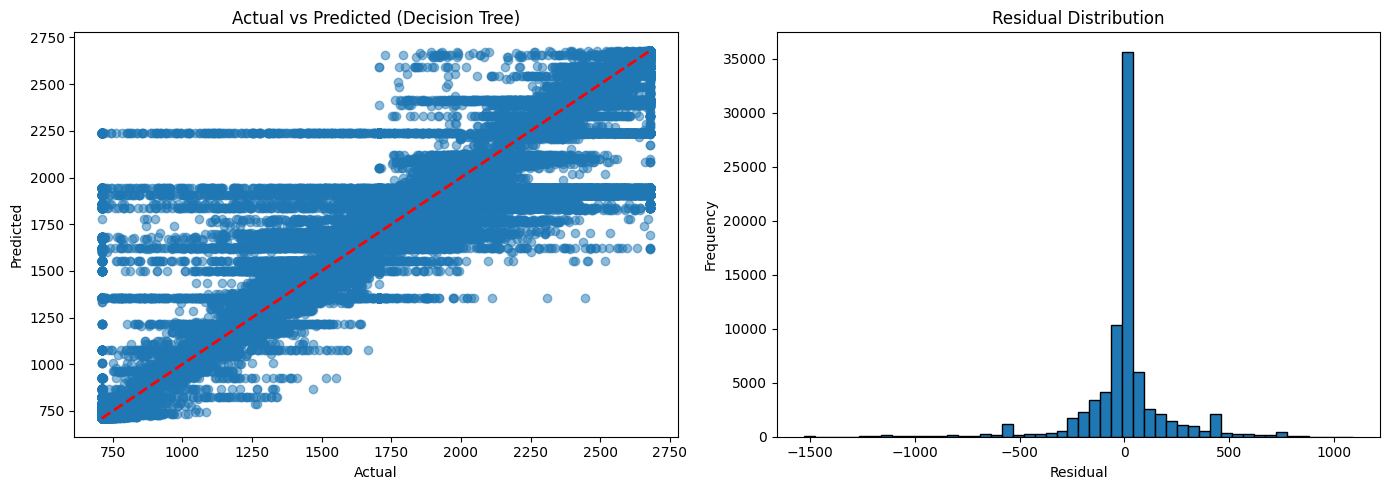

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.5)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Actual vs Predicted (Decision Tree)')

residuals = y_test - y_pred
axes[1].hist(residuals, bins=50, edgecolor='black')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig('../model/dt_actual_vs_predicted.png', dpi=150)
plt.show()

## Feature Importance

                feature  importance
18          cost_per_kg    0.520651
7             weight_kg    0.257856
11        base_cost_usd    0.110992
12        surcharge_usd    0.110487
0           shipment_id    0.000003
2         customer_name    0.000002
6   destination_country    0.000002
16          last_update    0.000002
17        delivery_days    0.000002
9         shipping_mode    0.000001


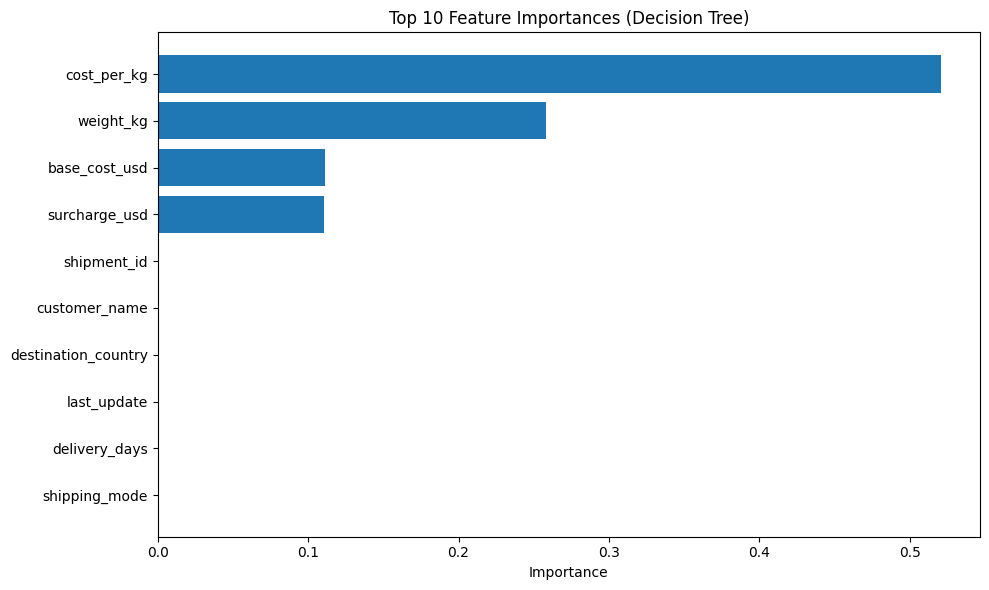

In [8]:
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': dt.feature_importances_
}).sort_values('importance', ascending=False)

print(importances.head(10))

plt.figure(figsize=(10, 6))
plt.barh(importances.head(10)['feature'], importances.head(10)['importance'])
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances (Decision Tree)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../model/dt_feature_importance.png', dpi=150)
plt.show()

## Tree Structure

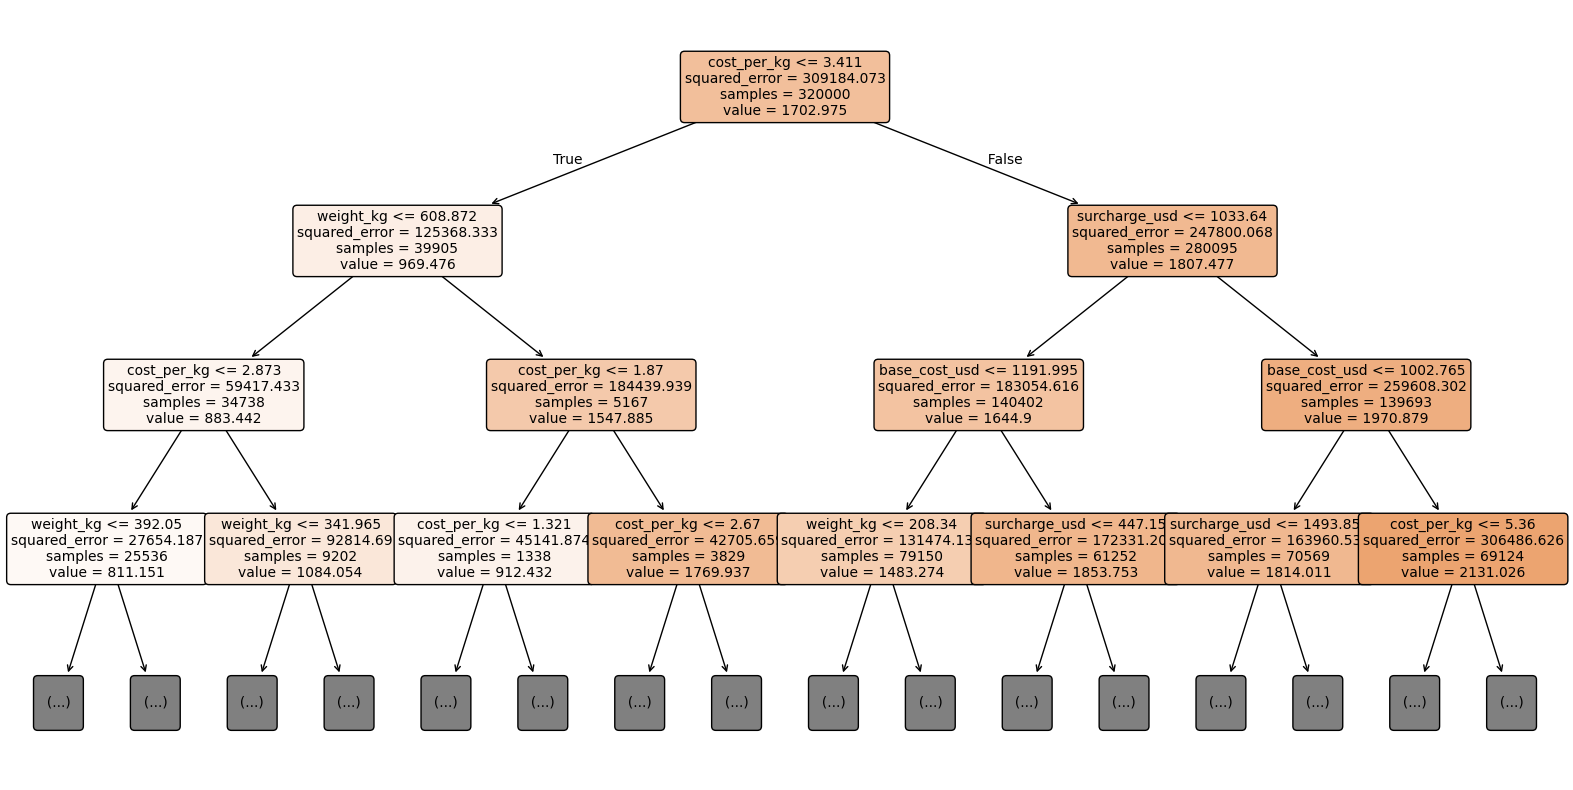

In [9]:
plt.figure(figsize=(20, 10))
plot_tree(dt, max_depth=3, feature_names=X.columns, filled=True, rounded=True, fontsize=10)
plt.savefig('../model/dt_tree_structure.png', dpi=150)
plt.show()

## Save Model

In [10]:
import joblib
joblib.dump(dt, '../model/decision_tree.pkl')
print('Model saved to ../model/decision_tree.pkl')

Model saved to ../model/decision_tree.pkl


## Compare Models

In [11]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_mae = metrics.mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(metrics.mean_squared_error(y_test, lr_pred))
lr_r2 = metrics.r2_score(y_test, lr_pred)

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree'],
    'MAE': [lr_mae, mae],
    'RMSE': [lr_rmse, rmse],
    'R2': [lr_r2, r2]
})
print(comparison)

best_model = comparison.loc[comparison['R2'].idxmax(), 'Model']
print(f'\nBest model based on R2: {best_model}')

               Model         MAE        RMSE        R2
0  Linear Regression  381.397557  475.998487  0.269899
1      Decision Tree  112.356624  215.463119  0.850405

Best model based on R2: Decision Tree


## Conclusion

This notebook performed feature engineering on the logistics dataset and trained a Decision Tree Regressor to predict total cost in USD. Key findings:

- **Feature engineering** created delivery_days, cost_per_kg, volume_per_kg, month, and year
- **Decision Tree** achieved an R2 score that is compared against a Linear Regression baseline
- **Cross-validation** provided a robust estimate of model performance
- **Feature importance** analysis identified the most predictive variables
- The model was saved to `../model/decision_tree.pkl` for future use

The Decision Tree offers interpretability via tree visualization and handles non-linear relationships better than linear regression.